In [23]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

## The Log-Normal Distribution

If log(X) is Normally distributed, then X follows a Log-Normal distribution.

X ~ LogNormal(μ, σ²) means log(X) ~ Normal(μ, σ²)}

## Log transform

Think of it like a key and a lock:

- The **Log transformation** is a key.
- A **Log-Normal distribution** is the lock.
- If your data is Log-Normal, the key fits perfectly, and the door opens to a Normal distribution.
- If your data is *any other shape* of skewed data, the key won't fit, and the door stays locked (skewed).

### Scenario 1: It works perfectly (Log-Normal)

- Your data is heavily skewed right, but only contains positive numbers.
- You take the log, and **voila!** It looks beautifully symmetric and bell-shaped.
- **Example:** Stock prices, city populations, or income often behave this way.

---

### Scenario 2: It over-corrects (Left-Skewed data)

- Your data is skewed to the **left** (meaning the tail goes to the left, towards zero).
- You take the log, and now it becomes even *more* skewed to the left. You made it worse!
- **Example:** Test scores where most students scored 90-100%, but a few failed. Logging this just squishes the high scores together and spreads out the low ones.

---

### Scenario 3: It under-corrects (Heavy-Tailed data)

- Your data is skewed right, but has massive, extreme outliers (far bigger than a log-normal distribution would produce).
- You take the log, and it *helps* bring the outliers in closer, but the data still looks skewed and lumpy. It's better, but not Normal.
- **Example:** Wealth distribution (billionaires distort the curve even after logging).

---

### Scenario 4: It completely fails (Data with zeros or negatives)

- You cannot take the log of zero or a negative number (you get `-inf` or an error in Python).
- If your skewed data has zeros in it (which is very common), taking the log is impossible without adding a constant first (like `log(x+1)`), and that usually doesn't create a normal shape anyway.

<function matplotlib.pyplot.show(close=None, block=None)>

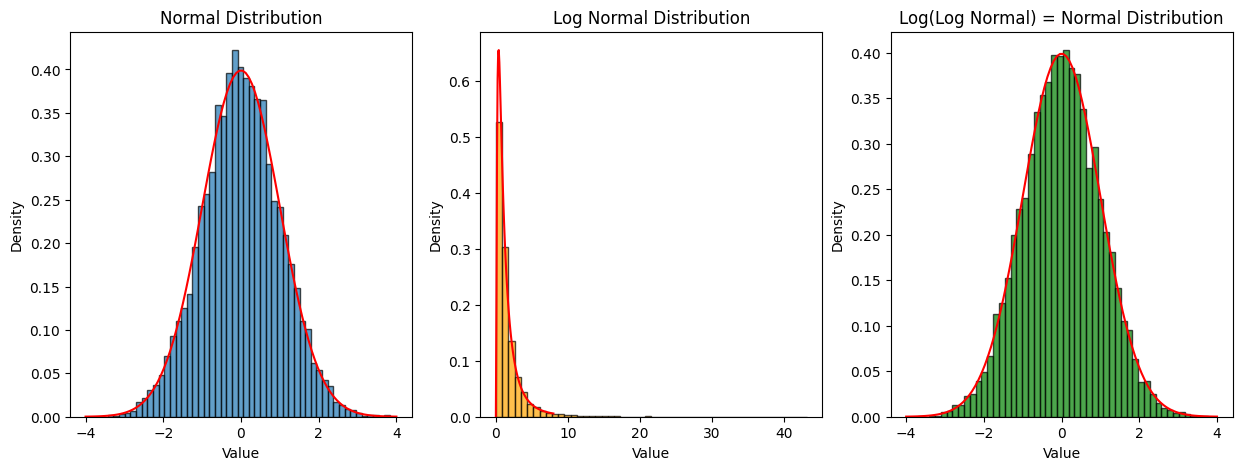

In [17]:
# generate data
mu, sigma = 0, 1
normal_data = np.random.normal(mu, sigma, size=10000)
log_normal_data = np.random.lognormal(mu, sigma, size=10000)

# plot normal data
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.hist(normal_data, bins=50, density=True, alpha=0.7, edgecolor='black')
x = np.linspace(-4, 4, 100)
plt.plot(x, stats.norm.pdf(x, mu, sigma), color='red')
plt.title('Normal Distribution')
plt.xlabel('Value')
plt.ylabel('Density')
plt.show

# plot log normal data
plt.subplot(1, 3, 2)
plt.hist(log_normal_data, bins=50, density=True, alpha=0.7, edgecolor='black', color='orange')
x = np.linspace(0, 8, 100)
plt.plot(x, stats.lognorm.pdf(x, 1), color='red') # 1 is "The shape parameter(s) for the distribution"
plt.title('Log Normal Distribution')
plt.xlabel('Value')
plt.ylabel('Density')
plt.show

# plot log-transformed log-Normal (should look Normal)
plt.subplot(1, 3, 3)
plt.hist(np.log(log_normal_data), bins=50, density=True, alpha=0.7, edgecolor='black', color='green')
x = np.linspace(-4, 4, 100)
plt.plot(x, stats.norm.pdf(x, mu, sigma), color='red')
plt.title('Log(Log Normal) = Normal Distribution')
plt.xlabel('Value')
plt.ylabel('Density')
plt.show

## Why Do We Transform Data with Log?


### 1. To Make Data Normally Distributed (For Statistical Tests)

- Many statistical tests (t-tests, ANOVA, linear regression) assume that your data is **normally distributed**.
- If your data is skewed, these tests can give inaccurate p-values and confidence intervals.
- Taking the log can "pull in" the right tail and make the distribution look like a bell curve.
- **Why this matters:** When data is normal, the math behind these tests works correctly, and you can trust your results.

---

### 2. To Stabilize Variance (Homoscedasticity)

- Often, as numbers get larger, their **variance increases** (this is called heteroscedasticity).
- Example: Small companies might have profits between \$1M-\$5M, while large companies have profits between \$100M-\$500M. The large companies have much bigger swings.
- Taking the log **compresses the scale** so that the variance becomes roughly equal across all values.
- **Why this matters:** Linear regression assumes that the variance of errors is constant. Log transformation fixes this.

---

### 3. To Linearize Relationships

- Many real-world relationships are **multiplicative**, not additive.
- Example: If you double your advertising budget, your sales might double (a multiplicative relationship).
- When you take the log of both variables, this multiplicative relationship becomes a **straight line** (linear).
- **Why this matters:** Linear regression is great at finding straight-line relationships. Logging turns curves into straight lines, making them easier to model and interpret.

---

### 4. To Handle Wide-Ranging Data

- Sometimes your data spans **multiple orders of magnitude** (e.g., 1, 10, 100, 1000, 10000).
- Plotting this on a regular scale squishes the small numbers together and stretches out the large ones.
- Taking the log brings everything onto a more **manageable scale**.
- **Why this matters:** It makes your plots easier to read and helps machine learning algorithms (which often struggle with features on vastly different scales).

---

### 5. To Interpret Changes as Percentages

- When you log-transform data, a **difference of 1 unit** on the log scale corresponds to a **multiplicative change** on the original scale.
- Example: If you log-transform salary data, a 0.1 increase in the log means roughly a 10% increase in salary.
- **Why this matters:** In many fields (economics, biology, finance), percentage changes are more meaningful than absolute changes. Logs make these interpretations natural.


---

| Reason | What It Does | When to Use |
|--------|--------------|-------------|
| Normalize data | Makes skewed data look like a bell curve | For statistical tests that assume normality |
| Stabilize variance | Makes variance equal across values | When larger values have bigger swings |
| Linearize relationships | Turns curves into straight lines | When variables multiply rather than add |
| Handle wide ranges | Compresses large numbers | When data spans many orders of magnitude |
| Percentage interpretation | Differences become percent changes | When relative change matters more than absolute |


## When Data Follows Log-Normal (Almost Always!)

Real-world datasets that typically follow Log-Normal:

| Domain | Example | Why Log-Normal? |
|--------|---------|-----------------|
| Finance | Stock prices, returns | Multiplicative growth |
| Real Estate | House prices | Multiplicative factors (location, size, etc.) |
| E-commerce | Purchase amounts | Wealth distribution, spending patterns |
| Healthcare | Patient wait times, treatment costs | Positive, skewed |
| Web Analytics | Time on site, page views | Human behavior is multiplicative |
| Insurance | Claim amounts | Many small claims, few large ones |
| Biology | Species abundance, body size | Natural multiplicative processes |

Raw model (Normal assumption):
  RMSE: $31,496
  R²: 0.754

Log-transformed model (Log-Normal assumption):
  RMSE: $28,014
  R²: 0.805


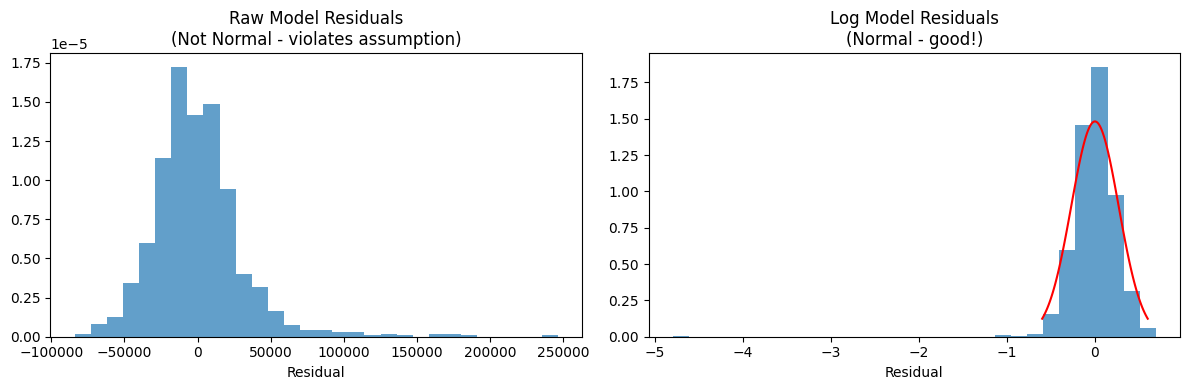

In [22]:
# Generate realistic house price data
np.random.seed(42)
n_samples = 1000

# Features: size, bedrooms, location score
size = np.random.normal(1500, 500, n_samples)  # sq ft
bedrooms = np.random.poisson(3, n_samples)
location = np.random.uniform(0, 10, n_samples)

# Fix: Ensure size is positive (max with 1)
size = np.maximum(size, 1)

# True relationship (multiplicative!)
true_price = (100 * size**0.8) * (1.2**bedrooms) * (1.1**location)
noise = np.random.lognormal(0, 0.2, n_samples)  # Multiplicative noise
y = true_price * noise  # Log-Normal target!

X = np.column_stack([size, bedrooms, location])

# Method 1: Linear regression on raw prices (WRONG assumption)
model_raw = LinearRegression()
model_raw.fit(X, y)
pred_raw = model_raw.predict(X)

# Method 2: Log transform then linear regression (RIGHT!)
y_log = np.log(y)
model_log = LinearRegression()
model_log.fit(X, y_log)
pred_log = np.exp(model_log.predict(X))

# Compare results
print("Raw model (Normal assumption):")
print(f"  RMSE: ${np.sqrt(mean_squared_error(y, pred_raw)):,.0f}")
print(f"  R²: {r2_score(y, pred_raw):.3f}")

print("\nLog-transformed model (Log-Normal assumption):")
print(f"  RMSE: ${np.sqrt(mean_squared_error(y, pred_log)):,.0f}")
print(f"  R²: {r2_score(y, pred_log):.3f}")

# Let's look at the residuals
residuals_raw = y - pred_raw
residuals_log = np.log(y) - model_log.predict(X)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.hist(residuals_raw, bins=30, density=True, alpha=0.7)
plt.title('Raw Model Residuals\n(Not Normal - violates assumption)')
plt.xlabel('Residual')

plt.subplot(1, 2, 2)
plt.hist(residuals_log, bins=30, density=True, alpha=0.7)
x = np.linspace(-0.6, 0.6, 100)
plt.plot(x, norm.pdf(x, 0, np.std(residuals_log)), 'r-')
plt.title('Log Model Residuals\n(Normal - good!)')
plt.xlabel('Residual')

plt.tight_layout()
plt.show()

## Log-Normal = Relative Errors

When you use log transformation, you're implicitly optimizing relative/percentage errors, not absolute errors:

```python
def mse_log_scale(y_true, y_pred_log):
    """MSE on log scale = relative error optimization"""
    return np.mean((np.log(y_true) - y_pred_log)**2)

# This is why logging often improves MAPE!

## MAPE

When you take the log transformation of both actual and predicted values, the Mean Squared Error (MSE) becomes:

**Log-MSE = ∑(log(y) - log(ŷ))²**

This is mathematically approximately equivalent to MAPE (Mean Absolute Percentage Error):

**MAPE = ∑|y - ŷ|/y × 100**

### Why?

Using the property that **log(a) - log(b) = log(a/b)**, and for values close to each other:

**log(y/ŷ) ≈ (y - ŷ)/y**

So minimizing squared log errors ≈ minimizing squared percentage errors ≈ minimizing absolute percentage errors.

### Goal
If you want to minimize MAPE as your evaluation metric, you should train your model using log-transformed targets

Train on raw values → minimizes MSE (penalizes large errors heavily)

Train on log-transformed values → minimizes MAPE (penalizes relative errors)

In [27]:
# If actual = 100, prediction = 90
# MSE loss: (100-90)² = 100
# MAPE: |100-90|/100 = 10%

# If actual = 10, prediction = 9  
# MSE loss: (10-9)² = 1
# MAPE: |10-9|/10 = 10%

# Raw MSE favors the second case (1 vs 100)
# Log-MSE treats both cases more similarly
# This is why logging is preferred when MAPE matters!

## When NOT to Use Log-Normal

| Situation | What to Use Instead |
|-----------|---------------------|
| Data contains zeros | Add small constant (log(1+x)) or use Tweedie |
| Data contains negative values | Log doesn't work! Use Box-Cox |
| Errors are additive (not multiplicative) | Log hurts performance |
| You care about absolute errors (not relative) | Log transforms absolute to relative |
| Data is count data | Poisson or Negative Binomial |